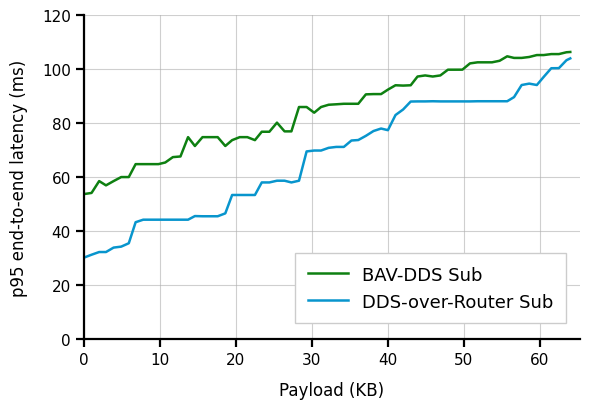

Saved PDF: Latency.pdf


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# Input / Output
# =====================
INPUT_CSV_FILE = r'E:\DDScode\exp\p2plantency.csv'
INPUT_CSV_FILE_2 = r'E:\DDScode\exp\roulantency.csv'
PDF_OUTPUT_FILE = 'Latency.pdf'

# =====================
# Plot Style
# =====================
FIGURE_SIZE = (6, 4.2)

LINE_COLOR_1 = '#0E8011'   # BAV-DDS
LINE_COLOR_2 = '#0895CD'   # Roulan-DDS

LINE_WIDTH = 1.8
TICK_WIDTH = 1.6
SPINE_WIDTH = 1.6
TICK_LENGTH = 6
AXIS_LABEL_SIZE = 12
TICK_LABEL_SIZE = 11
AXIS_LABEL_PAD = 10
GRID_LINEWIDTH = 0.8
GRID_ALPHA = 0.6
LEGEND_FONTSIZE = 13
LEGEND_HANDLE_LENGTH = 2.2
LEGEND_HANDLE_LINEWIDTH = 2.4
LEGEND_BORDERPAD = 0.7
LEGEND_HANDLE_TEXTPAD = 0.8

# ✅ 你的要求：y轴上限120，刻度0/20/40...
Y_MAX = 120
Y_TICK_STEP = 20

# =====================
# Data Reading
# =====================
def read_latency_csv(filepath: str) -> pd.DataFrame:
    """
    读取 CSV：
    第二列 -> payload (x)
    第三列 -> latency (y)
    第一列忽略
    """
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File '{filepath}' not found!")
    df = pd.read_csv(filepath, header=None, names=['ignore', 'payload', 'latency'])
    return df[['payload', 'latency']]

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """payload 重复时保留最后一次"""
    if df is None or df.empty:
        return df
    return (df.sort_values('payload')
              .groupby('payload', as_index=False)
              .last()
              .sort_values('payload')
              .reset_index(drop=True))

# =====================
# Plotting
# =====================
def plot_latency_vs_payload(df1: pd.DataFrame, df2: pd.DataFrame, pdf_output_path: str) -> None:
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    # 曲线
    ax.plot(df1['payload'], df1['latency'],
            color=LINE_COLOR_1, linewidth=LINE_WIDTH, label='BAV-DDS Sub')

    ax.plot(df2['payload'], df2['latency'],
            color=LINE_COLOR_2, linewidth=LINE_WIDTH, label='DDS-over-Router Sub')

    # 坐标轴标签
    ax.set_xlabel('Payload (KB)', fontsize=AXIS_LABEL_SIZE, labelpad=AXIS_LABEL_PAD)
    ax.set_ylabel('p95 end-to-end latency (ms)', fontsize=AXIS_LABEL_SIZE, labelpad=AXIS_LABEL_PAD)

    # 网格
    ax.grid(True, linestyle='-', linewidth=GRID_LINEWIDTH, alpha=GRID_ALPHA)

    # 刻度样式
    ax.tick_params(axis='both', which='major',
                   width=TICK_WIDTH, length=TICK_LENGTH,
                   labelsize=TICK_LABEL_SIZE)

    # ✅ 你的要求：FastDDS风格边框（去掉上/右边框）
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(SPINE_WIDTH)
    ax.spines['bottom'].set_linewidth(SPINE_WIDTH)

    # ✅ 只保留左/下刻度，不显示上/右刻度
    ax.tick_params(axis='both', which='both', top=False, right=False)

    # x范围
    xmin = min(df1['payload'].min(), df2['payload'].min())
    xmax = max(df1['payload'].max(), df2['payload'].max())
    ax.set_xlim(xmin * 0.98, xmax * 1.02)

    # ✅ 你的要求：y范围与刻度
    ax.set_ylim(0, Y_MAX)
    ax.set_yticks(np.arange(0, Y_MAX + 1, Y_TICK_STEP))

    # 图例
    ax.legend(loc='lower right',
          bbox_to_anchor=(0.99, 0.02),
          fontsize=LEGEND_FONTSIZE,
          handlelength=LEGEND_HANDLE_LENGTH,
          handletextpad=LEGEND_HANDLE_TEXTPAD,
          borderpad=LEGEND_BORDERPAD,
          frameon=True,
          fancybox=False,
          framealpha=1.0)

    plt.tight_layout()
    plt.savefig(pdf_output_path, format='pdf', bbox_inches='tight')
    plt.show()

# =====================
# Main
# =====================
def main():
    try:
        df1 = clean_data(read_latency_csv(INPUT_CSV_FILE))
        df2 = clean_data(read_latency_csv(INPUT_CSV_FILE_2))
    except FileNotFoundError as e:
        print(e)
        return

    if df1.empty or df2.empty:
        print("One of the datasets is empty.")
        return

    plot_latency_vs_payload(df1, df2, PDF_OUTPUT_FILE)
    print(f"Saved PDF: {PDF_OUTPUT_FILE}")

if __name__ == '__main__':
    main()


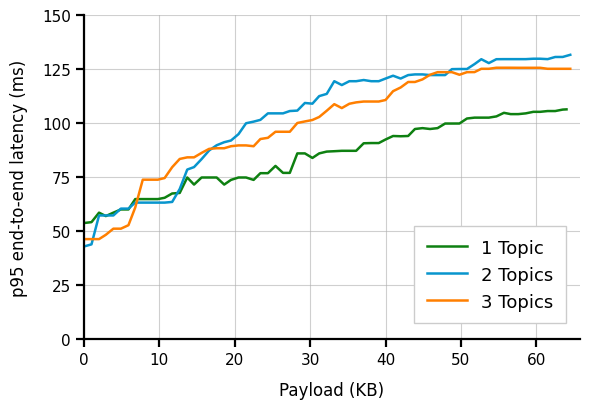

Saved PDF: Multtopic.pdf


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# Input / Output
# =====================
INPUT_CSV_FILE = r'E:\DDScode\exp\1topic.csv'
INPUT_CSV_FILE_2 = r'E:\DDScode\exp\2topic.csv'
INPUT_CSV_FILE_3 = r'E:\DDScode\exp\3topic.csv'  # 添加第三个CSV文件

PDF_OUTPUT_FILE = 'Multtopic.pdf'  # 修改输出PDF文件名为 Multtopic.pdf

# =====================
# Plot Style
# =====================
FIGURE_SIZE = (6, 4.2)

LINE_COLOR_1 = '#0E8011'   # BAV-DDS (Green)
LINE_COLOR_2 = '#0895CD'   # Roulan-DDS (Blue)
LINE_COLOR_3 = '#FF7F00'   # New color for the third curve (Orange)

LINE_WIDTH = 1.8
TICK_WIDTH = 1.6
SPINE_WIDTH = 1.6
TICK_LENGTH = 6
AXIS_LABEL_SIZE = 12
TICK_LABEL_SIZE = 11
AXIS_LABEL_PAD = 10
GRID_LINEWIDTH = 0.8
GRID_ALPHA = 0.6
LEGEND_FONTSIZE = 13
LEGEND_HANDLE_LENGTH = 2.2
LEGEND_HANDLE_LINEWIDTH = 2.4
LEGEND_BORDERPAD = 0.7
LEGEND_HANDLE_TEXTPAD = 0.8

# ✅ 你的要求：y轴上限改为150，刻度为0, 25, 50, 75, 100, 125, 150
Y_MAX = 150  # 修改y轴上限为150

# 自定义刻度
Y_TICKS = [0, 25, 50, 75, 100, 125, 150]

# =====================
# Data Reading
# =====================
def read_latency_csv(filepath: str) -> pd.DataFrame:
    """
    读取 CSV：
    第一列 -> payload (x)
    第二列 -> latency (y)
    """
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File '{filepath}' not found!")
    df = pd.read_csv(filepath, header=None, names=['payload', 'latency'])
    return df[['payload', 'latency']]

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """payload 重复时保留最后一次"""
    if df is None or df.empty:
        return df
    return (df.sort_values('payload')
              .groupby('payload', as_index=False)
              .last()
              .sort_values('payload')
              .reset_index(drop=True))

# =====================
# Plotting
# =====================
def plot_latency_vs_payload(df1: pd.DataFrame, df2: pd.DataFrame, df3: pd.DataFrame, pdf_output_path: str) -> None:
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    # 曲线
    ax.plot(df1['payload'], df1['latency'],
            color=LINE_COLOR_1, linewidth=LINE_WIDTH, label='1 Topic')

    ax.plot(df2['payload'], df2['latency'],
            color=LINE_COLOR_2, linewidth=LINE_WIDTH, label='2 Topics')

    ax.plot(df3['payload'], df3['latency'],
            color=LINE_COLOR_3, linewidth=LINE_WIDTH, label='3 Topics')  # 添加第三条曲线

    # 坐标轴标签
    ax.set_xlabel('Payload (KB)', fontsize=AXIS_LABEL_SIZE, labelpad=AXIS_LABEL_PAD)
    ax.set_ylabel('p95 end-to-end latency (ms)', fontsize=AXIS_LABEL_SIZE, labelpad=AXIS_LABEL_PAD)

    # 网格
    ax.grid(True, linestyle='-', linewidth=GRID_LINEWIDTH, alpha=GRID_ALPHA)

    # 刻度样式
    ax.tick_params(axis='both', which='major',
                   width=TICK_WIDTH, length=TICK_LENGTH,
                   labelsize=TICK_LABEL_SIZE)

    # ✅ 你的要求：FastDDS风格边框（去掉上/右边框）
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(SPINE_WIDTH)
    ax.spines['bottom'].set_linewidth(SPINE_WIDTH)

    # ✅ 只保留左/下刻度，不显示上/右刻度
    ax.tick_params(axis='both', which='both', top=False, right=False)

    # x范围
    xmin = min(df1['payload'].min(), df2['payload'].min(), df3['payload'].min())
    xmax = max(df1['payload'].max(), df2['payload'].max(), df3['payload'].max())
    ax.set_xlim(xmin * 0.98, xmax * 1.02)

    # ✅ 你的要求：y范围与刻度
    ax.set_ylim(0, Y_MAX)
    ax.set_yticks(Y_TICKS)  # 使用自定义刻度

    # 图例
    ax.legend(loc='lower right',
              bbox_to_anchor=(0.99, 0.02),
              fontsize=LEGEND_FONTSIZE,
              handlelength=LEGEND_HANDLE_LENGTH,
              handletextpad=LEGEND_HANDLE_TEXTPAD,
              borderpad=LEGEND_BORDERPAD,
              frameon=True,
              fancybox=False,
              framealpha=1.0)

    plt.tight_layout()
    plt.savefig(pdf_output_path, format='pdf', bbox_inches='tight')
    plt.show()

# =====================
# Main
# =====================
def main():
    try:
        df1 = clean_data(read_latency_csv(INPUT_CSV_FILE))
        df2 = clean_data(read_latency_csv(INPUT_CSV_FILE_2))
        df3 = clean_data(read_latency_csv(INPUT_CSV_FILE_3))  # 读取第三个CSV文件
    except FileNotFoundError as e:
        print(e)
        return

    if df1.empty or df2.empty or df3.empty:
        print("One of the datasets is empty.")
        return

    plot_latency_vs_payload(df1, df2, df3, PDF_OUTPUT_FILE)
    print(f"Saved PDF: {PDF_OUTPUT_FILE}")

if __name__ == '__main__':
    main()


C:\Users\Zou Zhongtao\AppData\Local\Temp\ipykernel_17332\1002797692.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved PDF: onchain.pdf
Saved PNG: onchain.png


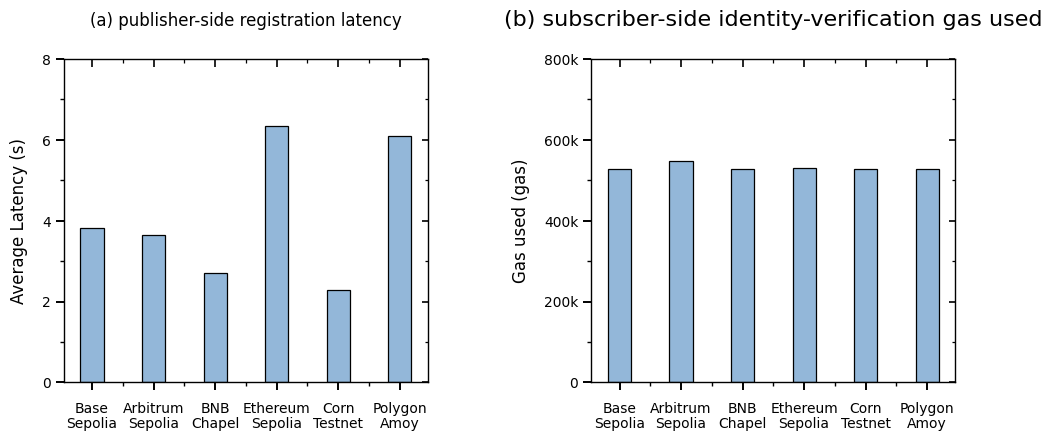

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedLocator, FuncFormatter, FormatStrFormatter

# =====================
# Configuration
# =====================

FIGURE_SIZE = (11.5, 4.2)
WSPACE = 0.45

BAR_COLOR = '#93B7D9'
BAR_EDGE_COLOR = 'black'
BAR_ALPHA = 1.0

SPINE_WIDTH = 1.0

# bottom/left (OUT)
TICK_WIDTH_BL = 1.4
TICK_LENGTH_BL = 6
MINOR_TICK_WIDTH_BL = 1.0
MINOR_TICK_LENGTH_BL = 3

# top (IN)
TICK_WIDTH_TOP = 1.2
TICK_LENGTH_TOP = 6
MINOR_TICK_WIDTH_TOP = 0.9
MINOR_TICK_LENGTH_TOP = 3

# right (IN)  ✅ 比 top 更短
TICK_WIDTH_RIGHT = 1.2
TICK_LENGTH_RIGHT = 4
MINOR_TICK_WIDTH_RIGHT = 0.9
MINOR_TICK_LENGTH_RIGHT = 2

AXIS_LABEL_SIZE = 12
TICK_LABEL_SIZE = 10
AXIS_LABEL_PAD = 10


def _wrap_two_words(label: str) -> str:
    parts = label.split()
    if len(parts) == 2:
        return parts[0] + "\n" + parts[1]
    return label


def _k_formatter(x, pos):
    if abs(x) < 1e-9:
        return "0"
    return f"{int(round(x / 1000.0))}k"


def _set_full_box_spines(ax):
    ax.grid(False)
    for side in ['left', 'bottom', 'right', 'top']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(SPINE_WIDTH)


def _set_x_ticks_with_one_minor(ax, x_positions, x_labels_wrapped):
    ax.xaxis.set_major_locator(FixedLocator(x_positions))
    ax.set_xticklabels(x_labels_wrapped, fontsize=TICK_LABEL_SIZE, ha='center')

    # exactly one minor tick between categories (midpoints)
    if len(x_positions) >= 2:
        mids = (x_positions[:-1] + x_positions[1:]) / 2.0
        ax.xaxis.set_minor_locator(FixedLocator(mids))
    else:
        ax.xaxis.set_minor_locator(FixedLocator([]))


def _set_y_axis(ax, y_min, y_max, y_major_step, formatter=None):
    ax.set_ylim(y_min, y_max)
    ax.yaxis.set_major_locator(MultipleLocator(y_major_step))
    ax.yaxis.set_minor_locator(MultipleLocator(y_major_step / 2))  # exactly one minor between majors

    if formatter is None:
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    else:
        ax.yaxis.set_major_formatter(formatter)


def _style_bottom_left_out(ax):
    """主轴：bottom/left 朝外，top/right 不画（交给 secondary axis）"""
    ax.tick_params(axis='x', which='major',
                   bottom=True, top=False,
                   direction='out',
                   width=TICK_WIDTH_BL, length=TICK_LENGTH_BL,
                   labelsize=TICK_LABEL_SIZE)
    ax.tick_params(axis='x', which='minor',
                   bottom=True, top=False,
                   direction='out',
                   width=MINOR_TICK_WIDTH_BL, length=MINOR_TICK_LENGTH_BL)

    ax.tick_params(axis='y', which='major',
                   left=True, right=False,
                   direction='out',
                   width=TICK_WIDTH_BL, length=TICK_LENGTH_BL,
                   labelsize=TICK_LABEL_SIZE)
    ax.tick_params(axis='y', which='minor',
                   left=True, right=False,
                   direction='out',
                   width=MINOR_TICK_WIDTH_BL, length=MINOR_TICK_LENGTH_BL)


def _add_top_right_in_axes(ax):
    """
    用 secondary_xaxis/top + secondary_yaxis/right：
    - top/right ticks inward
    - no labels on top/right
    - locators mirror main axis (including our custom minor ticks)
    """
    ax_top = ax.secondary_xaxis('top', functions=(lambda x: x, lambda x: x))
    ax_right = ax.secondary_yaxis('right', functions=(lambda y: y, lambda y: y))

    # mirror locators / formatter
    ax_top.xaxis.set_major_locator(ax.xaxis.get_major_locator())
    ax_top.xaxis.set_minor_locator(ax.xaxis.get_minor_locator())

    ax_right.yaxis.set_major_locator(ax.yaxis.get_major_locator())
    ax_right.yaxis.set_minor_locator(ax.yaxis.get_minor_locator())
    ax_right.yaxis.set_major_formatter(ax.yaxis.get_major_formatter())

    # hide secondary spines (main axis already draws the full box)
    for s in ['top', 'bottom', 'left', 'right']:
        ax_top.spines[s].set_visible(False)
        ax_right.spines[s].set_visible(False)

    # top inward (longer)
    ax_top.tick_params(axis='x', which='major',
                       direction='in',
                       width=TICK_WIDTH_TOP, length=TICK_LENGTH_TOP,
                       labeltop=False, labelsize=TICK_LABEL_SIZE)
    ax_top.tick_params(axis='x', which='minor',
                       direction='in',
                       width=MINOR_TICK_WIDTH_TOP, length=MINOR_TICK_LENGTH_TOP,
                       labeltop=False)

    # right inward (shorter) ✅
    ax_right.tick_params(axis='y', which='major',
                         direction='in',
                         width=TICK_WIDTH_RIGHT, length=TICK_LENGTH_RIGHT,
                         labelright=False, labelsize=TICK_LABEL_SIZE)
    ax_right.tick_params(axis='y', which='minor',
                         direction='in',
                         width=MINOR_TICK_WIDTH_RIGHT, length=MINOR_TICK_LENGTH_RIGHT,
                         labelright=False)

    return ax_top, ax_right


def _hide_corner_ticks_on_secondary(fig, ax, ax_top, ax_right, tol=1e-9):
    """
    ✅ 只隐藏 top/right 在边界(角点)的 tick，不误伤中间的。
    重要：必须先 draw 一次，ticks 才会真正生成（否则拿到的是空或不完整）。
    """
    fig.canvas.draw()

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    def near(a, b):
        return abs(a - b) <= tol * max(1.0, abs(a), abs(b))

    # top axis: hide ticks at xlim bounds
    for t in ax_top.xaxis.get_major_ticks():
        loc = t.get_loc()
        if near(loc, xmin) or near(loc, xmax):
            t.tick1line.set_visible(False)  # top side on secondary axis
    for t in ax_top.xaxis.get_minor_ticks():
        loc = t.get_loc()
        if near(loc, xmin) or near(loc, xmax):
            t.tick1line.set_visible(False)

    # right axis: hide ticks at ylim bounds
    for t in ax_right.yaxis.get_major_ticks():
        loc = t.get_loc()
        if near(loc, ymin) or near(loc, ymax):
            t.tick1line.set_visible(False)  # right side on secondary axis
    for t in ax_right.yaxis.get_minor_ticks():
        loc = t.get_loc()
        if near(loc, ymin) or near(loc, ymax):
            t.tick1line.set_visible(False)


def plot_two_bar_panels(
    labels,
    values_left,
    values_right,
    pdf_output_path="bar_two_panels.pdf",
    png_output_path=None,
    y_label_left="Average Latency (s)",
    y_label_right="Gas used (gas)",
    x_gap=1.2,
    xtick_rotation=0,
    xtick_pad=8,
    xtick_linespacing=1.1,
    bar_width=0.45,
    # left y
    y_left_min=0,
    y_left_max=8,
    y_left_tick_step=2,
    # right y
    y_right_min=0,
    y_right_max=800000,
    y_right_tick_step=200000
):
    if len(labels) != len(values_left) or len(labels) != len(values_right):
        raise ValueError("labels, values_left, values_right must have the same length.")

    labels_wrapped = [_wrap_two_words(s) for s in labels]
    values_left = np.asarray(values_left, dtype=float)
    values_right = np.asarray(values_right, dtype=float)

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=FIGURE_SIZE,
        gridspec_kw={'wspace': WSPACE},
        sharey=False
    )

    x = np.arange(len(labels_wrapped), dtype=float) * x_gap

    # =====================
    # Left subplot
    # =====================
    ax1.bar(x, values_left, width=bar_width,
            color=BAR_COLOR, edgecolor=BAR_EDGE_COLOR, alpha=BAR_ALPHA, linewidth=0.9)
    ax1.set_title("(a) publisher-side registration latency", fontsize=AXIS_LABEL_SIZE, pad=24)
    _set_x_ticks_with_one_minor(ax1, x, labels_wrapped)
    ax1.tick_params(axis='x', pad=xtick_pad, rotation=xtick_rotation)
    for t in ax1.get_xticklabels():
        t.set_linespacing(xtick_linespacing)

    ax1.set_xlabel("")  # remove "Name of Blockchain"
    ax1.set_ylabel(y_label_left, fontsize=AXIS_LABEL_SIZE, labelpad=AXIS_LABEL_PAD)

    _set_y_axis(ax1, y_left_min, y_left_max, y_left_tick_step)
    _set_full_box_spines(ax1)
    _style_bottom_left_out(ax1)

    ax1_top, ax1_right = _add_top_right_in_axes(ax1)
    _hide_corner_ticks_on_secondary(fig, ax1, ax1_top, ax1_right)

    # =====================
    # Right subplot
    # =====================
    ax2.bar(x, values_right, width=bar_width,
            color=BAR_COLOR, edgecolor=BAR_EDGE_COLOR, alpha=BAR_ALPHA, linewidth=0.9)
    ax2.set_title("(b) subscriber-side identity-verification gas used", fontsize=AXIS_LABEL_SIZE, pad=24)
    _set_x_ticks_with_one_minor(ax2, x, labels_wrapped)
    ax2.tick_params(axis='x', pad=xtick_pad, rotation=xtick_rotation)
    for t in ax2.get_xticklabels():
        t.set_linespacing(xtick_linespacing)

    ax2.set_xlabel("")  # remove "Name of Blockchain"
    ax2.set_ylabel(y_label_right, fontsize=AXIS_LABEL_SIZE, labelpad=AXIS_LABEL_PAD)

    _set_y_axis(ax2, y_right_min, y_right_max, y_right_tick_step,
                formatter=FuncFormatter(_k_formatter))
    _set_full_box_spines(ax2)
    _style_bottom_left_out(ax2)

    ax2_top, ax2_right = _add_top_right_in_axes(ax2)
    _hide_corner_ticks_on_secondary(fig, ax2, ax2_top, ax2_right)

    plt.tight_layout()
    plt.savefig(pdf_output_path, format='pdf', bbox_inches='tight')
    print(f"Saved PDF: {pdf_output_path}")

    if png_output_path:
        plt.savefig(png_output_path, dpi=300, bbox_inches='tight')
        print(f"Saved PNG: {png_output_path}")

    plt.show()


# =====================
# Example usage
# =====================
if __name__ == "__main__":
    labels = [
        "Base Sepolia",
        "Arbitrum Sepolia",
        "BNB Chapel",
        "Ethereum Sepolia",
        "Corn Testnet",
        "Polygon Amoy"
    ]

    values_left = [3.815, 3.657, 2.706, 6.346, 2.284, 6.102]
    values_right = [529191, 546885, 529215, 529943, 529203, 529203]

    plot_two_bar_panels(
        labels,
        values_left=values_left,
        values_right=values_right,
        pdf_output_path="onchain.pdf",
        png_output_path="onchain.png",
        x_gap=1.2,
        y_left_tick_step=2,
        y_right_tick_step=200000
    )


Saved PDF: Throughout.pdf


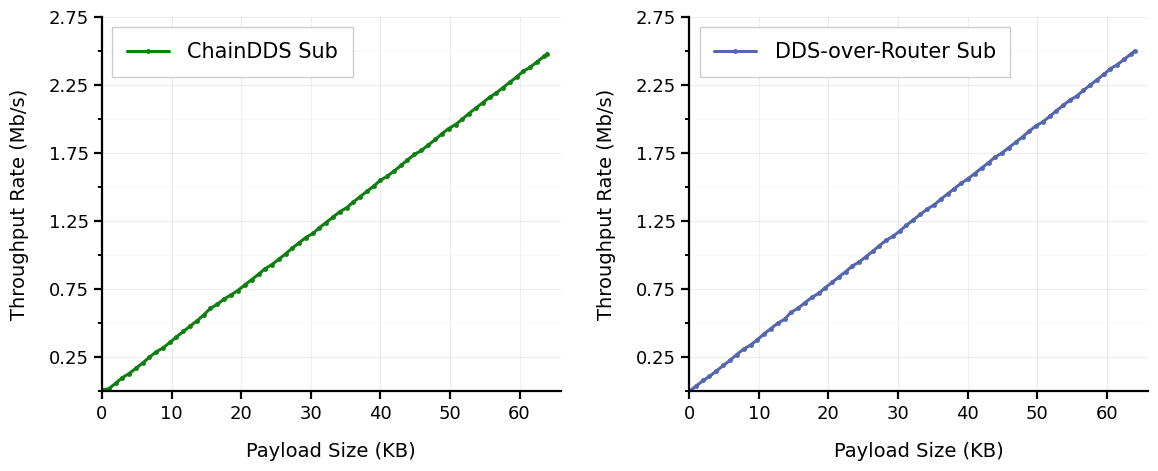

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import matplotlib.ticker as ticker

# =====================
# Configuration
# =====================

INPUT_CSV = r'E:\DDScode\exp\p2plantency.csv'          # 左图数据（原来的）
INPUT_CSV_ROUTER = r'E:\DDScode\exp\roulantency.csv'  # ✅ 右图新数据：col1->y, col2->x
PDF_OUTPUT_FILE = 'Throughout.pdf'

FIGURE_SIZE = (13.5, 5.2)

LINE_COLOR = '#0E8011'
ROUTER_LINE_COLOR = "#5566B1"

LINE_WIDTH = 2.2
MARKER = 'o'
MARKER_SIZE = 3.5
MARKER_EDGEWIDTH = 0.0

TICK_WIDTH = 1.6
SPINE_WIDTH = 1.6
TICK_LENGTH = 6

AXIS_LABEL_SIZE = 14
TICK_LABEL_SIZE = 13
AXIS_LABEL_PAD = 14

# 灰色实线网格（主网格/次网格分别控制强度）
GRID_LINEWIDTH_MAJOR = 0.8
GRID_ALPHA_MAJOR = 0.25
GRID_LINEWIDTH_MINOR = 0.6
GRID_ALPHA_MINOR = 0.12
GRID_COLOR = '0.75'

# y 轴：范围固定到 2.75
Y_LIM = (0, 2.75)

# 每 0.25 一格（minor），数字每 0.5 标一次（major）
Y_MINOR_STEP = 0.25
Y_MAJOR_STEP = 0.5

# x 轴刻度固定为 0, 10, 20, ...
X_TICK_STEP_KB = 10

# =====================
# Publication PDF tweaks
# =====================

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'DejaVu Sans'

# =====================
# Data Reading
# =====================

def read_lantency_csv(filepath: str) -> pd.DataFrame:
    """
    lantency.csv:
    col1 -> y (throughput)  第一列
    col2 -> x (payload KB)  第二列（直接用 KB）
    col3 -> ignore
    """
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File '{filepath}' not found!")

    df = pd.read_csv(filepath, header=None)
    if df.shape[1] < 2:
        raise ValueError("lantency.csv must have at least 2 columns.")

    df_out = pd.DataFrame({
        'payload_kb': pd.to_numeric(df.iloc[:, 1], errors='coerce'),
        'throughput': pd.to_numeric(df.iloc[:, 0], errors='coerce'),
    }).dropna()

    return df_out


def read_roulantency_csv(filepath: str) -> pd.DataFrame:
    """
    ✅ roulantency.csv:
    col1 -> y (throughput) 第一列
    col2 -> x (payload KB) 第二列
    其它列忽略
    """
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File '{filepath}' not found!")

    df = pd.read_csv(filepath, header=None)
    if df.shape[1] < 2:
        raise ValueError("roulantency.csv must have at least 2 columns.")

    df_out = pd.DataFrame({
        'payload_kb': pd.to_numeric(df.iloc[:, 1], errors='coerce'),   # 第二列 -> x
        'throughput': pd.to_numeric(df.iloc[:, 0], errors='coerce'),   # 第一列 -> y
    }).dropna()

    return df_out


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return df
    return df.sort_values('payload_kb').reset_index(drop=True)

# =====================
# Plotting
# =====================

def plot_throughput_vs_payload(df_chain: pd.DataFrame, df_router: pd.DataFrame, pdf_output_path: str):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGURE_SIZE, sharey=False)

    # ---- Left: BAV-DDS (from lantency.csv) ----
    ax1.plot(
        df_chain['payload_kb'], df_chain['throughput'],
        linewidth=LINE_WIDTH, color=LINE_COLOR,
        marker=MARKER, markersize=MARKER_SIZE, markeredgewidth=MARKER_EDGEWIDTH,
        solid_capstyle='round', solid_joinstyle='round'
    )

    # ---- Right: Router-based DDS (from roulantency.csv) ----
    ax2.plot(
        df_router['payload_kb'], df_router['throughput'],
        linewidth=LINE_WIDTH, color=ROUTER_LINE_COLOR,
        marker=MARKER, markersize=MARKER_SIZE, markeredgewidth=MARKER_EDGEWIDTH,
        solid_capstyle='round', solid_joinstyle='round'
    )

    # x: 刻度固定 0,10,20,...；xlim 右边界用真实最大值（更自然）
    x_max = float(max(df_chain['payload_kb'].max(), df_router['payload_kb'].max()))
    x_right_tick = np.floor(x_max / X_TICK_STEP_KB) * X_TICK_STEP_KB
    if x_right_tick <= 0:
        x_right_tick = X_TICK_STEP_KB
    x_ticks = np.arange(0, x_right_tick + 0.1, X_TICK_STEP_KB)
    x_right_lim = max(x_max * 1.03, x_max + 0.5)

    for ax in (ax1, ax2):
        ax.set_xlabel('Payload Size (KB)', fontsize=AXIS_LABEL_SIZE, labelpad=AXIS_LABEL_PAD)
        ax.set_ylabel('Throughput Rate (Mb/s)', fontsize=AXIS_LABEL_SIZE, labelpad=AXIS_LABEL_PAD)

        ax.set_xlim(0, x_right_lim)
        ax.set_xticks(x_ticks)

        # y 轴：每 0.25 一格（minor），数字每 0.5 标一次（major）
        ax.set_ylim(0, 2.75)
        y_ticks = np.arange(0.25, 2.75 + 1e-9, 0.5)
        ax.set_yticks(y_ticks)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

        ax.tick_params(
            axis='both', which='major',
            width=TICK_WIDTH, length=TICK_LENGTH,
            labelsize=TICK_LABEL_SIZE,
            top=False, right=False
        )
        # minor ticks 更短一些（更像论文）
        ax.tick_params(
            axis='y', which='minor',
            width=TICK_WIDTH * 0.9, length=max(3, int(TICK_LENGTH * 0.55)),
            right=False
        )

        # 主/次网格：实线灰色，次网格更淡
        ax.grid(True, which='major', linestyle='-',
                linewidth=GRID_LINEWIDTH_MAJOR, alpha=GRID_ALPHA_MAJOR, color=GRID_COLOR)
        ax.grid(True, which='minor', linestyle='-',
                linewidth=GRID_LINEWIDTH_MINOR, alpha=GRID_ALPHA_MINOR, color=GRID_COLOR)

        # 官方风格：去掉上/右边框，只留左/下
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(SPINE_WIDTH)
        ax.spines['bottom'].set_linewidth(SPINE_WIDTH)

    # ---- Legends ----
    ax1.legend(
        ['ChainDDS Sub'],
        loc='upper left',
        fontsize=15,
        frameon=True,
        fancybox=False,
        framealpha=1.0,
        borderpad=0.7,
        handlelength=2.0,
        handletextpad=0.9
    )

    ax2.legend(
        ['DDS-over-Router Sub'],
        loc='upper left',
        fontsize=15,
        frameon=True,
        fancybox=False,
        framealpha=1.0,
        borderpad=0.7,
        handlelength=2.0,
        handletextpad=0.9
    )

    fig.subplots_adjust(wspace=0.28, bottom=0.16)

    fig.savefig(pdf_output_path, format='pdf', bbox_inches='tight')
    print(f"Saved PDF: {pdf_output_path}")

    plt.show()

# =====================
# Main
# =====================

def main():
    try:
        df_chain = clean_data(read_lantency_csv(INPUT_CSV))
        df_router = clean_data(read_roulantency_csv(INPUT_CSV_ROUTER))
    except (FileNotFoundError, ValueError) as e:
        print(e)
        return

    if df_chain.empty or df_router.empty:
        print("No valid data to plot (one of the datasets is empty).")
        return

    plot_throughput_vs_payload(df_chain, df_router, PDF_OUTPUT_FILE)

if __name__ == '__main__':
    main()
